## FF DWI drift plot
-----------------------------------------
The aim of this script is to plot differences

In [39]:
# =========================
# Configuration 
# =========================

import os
import numpy as np
import nibabel as nib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from nilearn import plotting
from nilearn.image import smooth_img
import subprocess

## SET WORKING DIRECTORY
prj_path=r"/home/malberti/wks14/temp/FF_DWI_Drift" # main BIDS path /home/malberti/Unix_Folders/Sweep/Pilot/SW005
project="sub-" #Common name for folders and files, for example all my sweep files are named as "sw001_ss1_dwi_AP.nii || sw001_ss1_T1w.nii"
script=r'/home/malberti/wks14/temp/FF_DWI_Drift/Script'
metric="FA"

In [35]:
# ── Input ────────────────────────────────────────────────────────────────────
Asterix_c = [16, 17, 21, 25, 26, 29, 30, 32, 33, 34, 35, 36, 39, 40]   # ses-01
Asterix_w = [18, 19, 22, 23, 24, 27, 28, 31, 37, 38, 9999, 9998]       # ses-13
Obelix_c  = [18, 19, 22, 23, 24, 27, 28, 31, 37, 38, 9999, 9998]       # ses-01

Asterix - Cold: n=14
Asterix - Warmed-up: n=12
Obelix - Cold: n=12


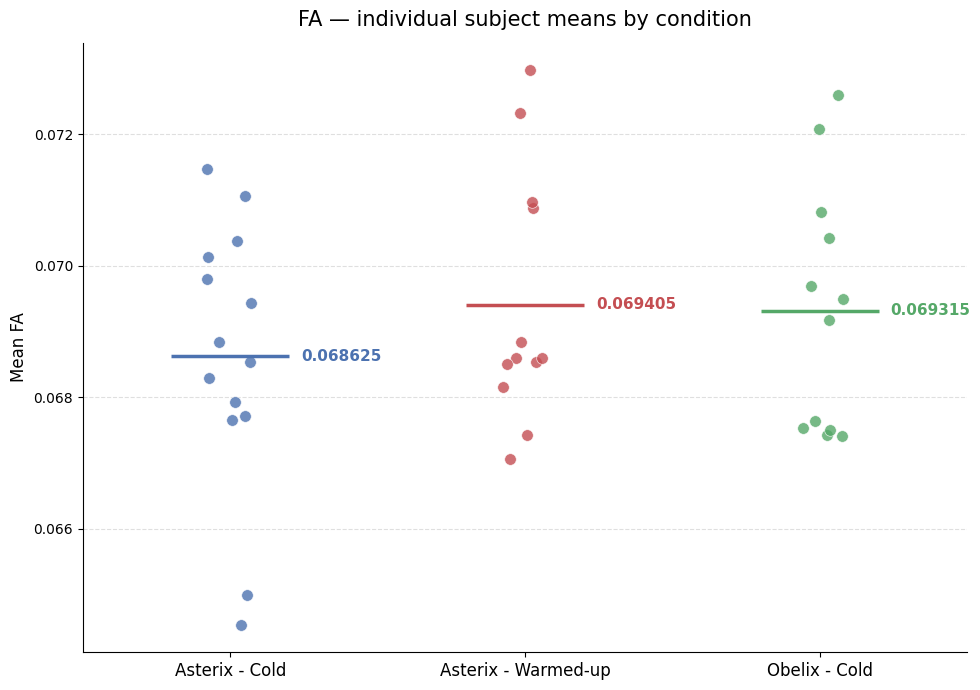

In [40]:
conditions = {
    "Asterix - Cold":      (Asterix_c, "01"),
    "Asterix - Warmed-up": (Asterix_w, "13"),
    "Obelix - Cold":       (Obelix_c,  "01"),
}
colors = ["#4C72B0", "#C44E52", "#55A868"]

# ── Load data ────────────────────────────────────────────────────────────────
all_means = []
for label, (sub_ids, ses) in conditions.items():
    means = []
    for sid in sub_ids:
        pid = f"sub-{sid:02d}"
        map_path = os.path.join(prj_path, "derivatives", pid, f"ses-{ses}", "dwi", "index", "Tensor", f"{pid}_ses-{ses}_prep_{metric}.nii")
        if not os.path.exists(map_path):
            print(f"  ! Missing {map_path}, skipping")
            continue
        vals = nib.load(map_path).get_fdata()
        vals = vals[(vals > 0) & (vals < 1)]

   

        means.append(np.mean(vals))
    all_means.append(means)

    if label == "Asterix - Cold": 
            ASTERIX_COLD = means
    if label == "Asterix - Warmed-up": 
            ASTERIX_WARM = means
    print(f"{label}: n={len(means)}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
labels = list(conditions.keys())
rng = np.random.default_rng(0)

for i, (means, color, label) in enumerate(zip(all_means, colors, labels)):
    x = i + rng.uniform(-0.08, 0.08, len(means))
    ax.scatter(x, means, color=color, s=70, alpha=0.8, zorder=3,
               edgecolor="white", linewidth=0.5)

    grand_mean = np.mean(means)
    ax.hlines(grand_mean, i - 0.2, i + 0.2, colors=color, linewidths=2.5, zorder=4)
    ax.text(i + 0.24, grand_mean, f"{grand_mean:4f}", va="center", ha="left", fontsize=11, color=color, fontweight="bold")

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=12)
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylabel(f"Mean {metric}", fontsize=12)
ax.set_title(f"{metric} — individual subject means by condition", fontsize=15, pad=12)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()



In [41]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    ASTERIX_COLD,
    ASTERIX_WARM,
    equal_var=False
)

print(f"Unpaired t-test:")
print(f"t = {t_stat:.3f}")
print(f"p = {p_value:.4g}")

Unpaired t-test:
t = -1.010
p = 0.3229
